In [1]:
# ── TRAIN LSTM ON REALISTIC FULL SEQUENCES ───────────────────────
# This trains original LSTM model on the realistic data splits

# ============================================================================
# CELL 1: IMPORTS & SETUP
# ============================================================================
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, 
                            confusion_matrix, classification_report,
                            roc_curve, precision_recall_curve)
import time
import warnings
warnings.filterwarnings('ignore')

# Set device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(" Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(" Using CUDA (NVIDIA GPU)")
else:
    device = torch.device("cpu")
    print(" Using CPU")

# Set random seeds
def set_seeds(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    elif torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seeds(42)

# Paths
DATA_DIR = Path("data/realistic_full_sequences")
OUTPUT_DIR = Path("models/realistic_lstm")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nData directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

 Using MPS (Apple Silicon GPU)

Data directory: data/realistic_full_sequences
Output directory: models/realistic_lstm


In [2]:
# ============================================================================
# CELL 2: LOAD REALISTIC DATA
# ============================================================================
print("Loading realistic full sequence data...")

# Load the splits
data = np.load(DATA_DIR / "realistic_full_splits.npz")
X_train = data['X_train']  # (n_train, 986, 129)
X_val = data['X_val']      # (n_val, 986, 129)
X_test = data['X_test']    # (n_test, 986, 129)
y_val = data['y_val']
y_test = data['y_test']

# Load config
with open(DATA_DIR / "config.pkl", "rb") as f:
    config = pickle.load(f)

print(f"\nData shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"\nLabels:")
print(f"  y_val: {y_val.sum()} anomalies ({y_val.mean():.1%})")
print(f"  y_test: {y_test.sum()} anomalies ({y_test.mean():.1%})")
print(f"\nConfiguration:")
print(f"  Sequence length: {config['seq_len']} timesteps")
print(f"  Features: {config['n_features']} sensors")

Loading realistic full sequence data...

Data shapes:
  X_train: (622, 986, 129)
  X_val:   (500, 986, 129)
  X_test:  (500, 986, 129)

Labels:
  y_val: 250 anomalies (50.0%)
  y_test: 5 anomalies (1.0%)

Configuration:
  Sequence length: 986 timesteps
  Features: 129 sensors


In [3]:
# ============================================================================
# CELL 3: LSTM AUTOENCODER MODEL (ORIGINAL ARCHITECTURE)
# ============================================================================
class LSTMAutoencoder(nn.Module):
    """
    LSTM Autoencoder for anomaly detection.
    This is the original architecture that worked well.
    """
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16, num_layers=1, dropout=0.0):
        super(LSTMAutoencoder, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers
        
        # Encoder LSTM
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Encoder fully connected (to latent space)
        self.encoder_fc = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder fully connected (from latent space)
        self.decoder_fc = nn.Linear(latent_dim, hidden_dim)
        
        # Decoder LSTM
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Output layer
        self.output_fc = nn.Linear(hidden_dim, input_dim)
        
    def encode(self, x):
        """Encode input sequence to latent representation"""
        # Pass through LSTM
        lstm_out, (hidden, cell) = self.encoder_lstm(x)
        
        # Take the last timestep output
        last_hidden = lstm_out[:, -1, :]
        
        # Project to latent space
        latent = self.encoder_fc(last_hidden)
        
        return latent
    
    def decode(self, latent, seq_len):
        """Decode latent representation back to sequence"""
        # Expand latent to sequence length
        latent_expanded = latent.unsqueeze(1).repeat(1, seq_len, 1)
        
        # Project to hidden dimension
        hidden = self.decoder_fc(latent_expanded)
        
        # Pass through decoder LSTM
        lstm_out, _ = self.decoder_lstm(hidden)
        
        # Generate reconstruction
        reconstruction = self.output_fc(lstm_out)
        
        return reconstruction
    
    def forward(self, x):
        """Forward pass: encode then decode"""
        seq_len = x.shape[1]
        latent = self.encode(x)
        reconstruction = self.decode(latent, seq_len)
        return reconstruction, latent

# Initialize model
input_dim = X_train.shape[2]  # 129 sensors
model = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dim=64,
    latent_dim=16,
    num_layers=1,
    dropout=0.0
).to(device)

print("LSTM Autoencoder Architecture:")
print(f"  Input dimension: {input_dim}")
print(f"  Hidden dimension: 64")
print(f"  Latent dimension: 16")
print(f"  Number of layers: 1")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device: {next(model.parameters()).device}")

LSTM Autoencoder Architecture:
  Input dimension: 129
  Hidden dimension: 64
  Latent dimension: 16
  Number of layers: 1
  Total parameters: 93,713
  Device: mps:0


In [5]:
# ============================================================================
# CELL 4: TRAINING SETUP 
# ============================================================================
print("\nSetting up training...")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)

# Create DataLoader
batch_size = 16  # Adjust based on your memory
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"Training configuration:")
print(f"  Batch size: {batch_size}")
print(f"  Learning rate: 0.001")
print(f"  Training batches: {len(train_loader)}")
print(f"  Total training samples: {len(X_train_tensor)}")


Setting up training...
Training configuration:
  Batch size: 16
  Learning rate: 0.001
  Training batches: 39
  Total training samples: 622


In [7]:
# ============================================================================
# CELL 5: TRAINING LOOP
# ============================================================================
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

num_epochs = 50
best_val_loss = float('inf')
best_val_auc = 0
patience = 10
patience_counter = 0

train_losses = []
val_losses = []
val_aucs = []

start_time = time.time()

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0
    for batch in train_loader:
        X_batch = batch[0]
        
        optimizer.zero_grad()
        reconstruction, _ = model(X_batch)
        loss = criterion(reconstruction, X_batch)
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0
    val_errors = []
    
    with torch.no_grad():
        for i in range(0, len(X_val_tensor), batch_size):
            batch = X_val_tensor[i:i+batch_size]
            reconstruction, _ = model(batch)
            loss = criterion(reconstruction, batch)
            val_loss += loss.item() * len(batch)
            
            # Per-sample reconstruction error
            mse = torch.mean((reconstruction - batch) ** 2, dim=(1, 2))
            val_errors.extend(mse.cpu().numpy())
    
    avg_val_loss = val_loss / len(X_val_tensor)
    val_losses.append(avg_val_loss)
    
    # Calculate validation AUC
    val_auc = roc_auc_score(y_val, val_errors)
    val_aucs.append(val_auc)
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save best model (based on AUC)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), OUTPUT_DIR / "best_lstm_model.pth")
        print(f"  ✓ New best model! (Epoch {epoch+1}, Val AUC: {val_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Progress report
    if (epoch + 1) % 5 == 0:
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | Val AUC: {val_auc:.4f} | LR: {current_lr:.6f} | Time: {elapsed:.1f}s")

total_time = time.time() - start_time
print(f"\n Training complete! Time: {total_time:.1f}s ({total_time/60:.1f} minutes)")
print(f"Best validation AUC: {best_val_auc:.4f}")
print(f"Best validation loss: {best_val_loss:.6f}")


STARTING TRAINING
  ✓ New best model! (Epoch 1, Val AUC: 0.3948)
  ✓ New best model! (Epoch 2, Val AUC: 0.4032)
  ✓ New best model! (Epoch 3, Val AUC: 0.5708)
  ✓ New best model! (Epoch 4, Val AUC: 0.6930)
  ✓ New best model! (Epoch 5, Val AUC: 0.7694)
Epoch [5/50] | Train Loss: 0.822449 | Val Loss: 0.757343 | Val AUC: 0.7694 | LR: 0.001000 | Time: 17.7s
Epoch [10/50] | Train Loss: 0.617978 | Val Loss: 0.611455 | Val AUC: 0.7018 | LR: 0.001000 | Time: 35.2s

Early stopping at epoch 15

 Training complete! Time: 52.6s (0.9 minutes)
Best validation AUC: 0.7694
Best validation loss: 0.757343


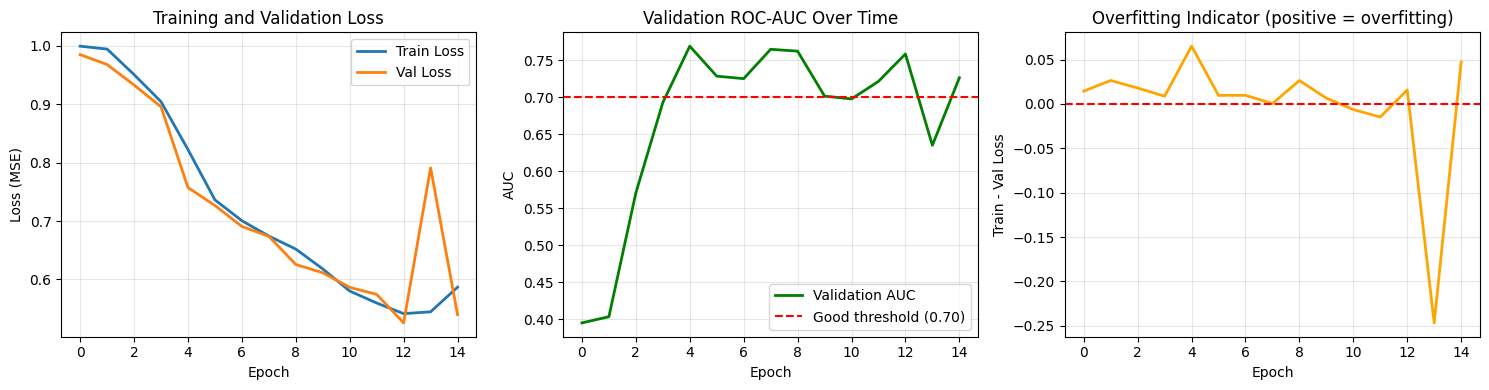

✓ Training curves saved to models/realistic_lstm/training_curves.png


In [8]:
# ============================================================================
# CELL 6: TRAINING VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC curve
axes[1].plot(val_aucs, label='Validation AUC', linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Validation ROC-AUC Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.7, color='red', linestyle='--', label='Good threshold (0.70)')
axes[1].legend()

# Loss difference (overfitting indicator)
loss_diff = [t - v for t, v in zip(train_losses, val_losses)]
axes[2].plot(loss_diff, linewidth=2, color='orange')
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Train - Val Loss')
axes[2].set_title('Overfitting Indicator (positive = overfitting)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
plt.show()
print(f"✓ Training curves saved to {OUTPUT_DIR}/training_curves.png")

In [9]:
# ============================================================================
# CELL 7: EVALUATE ON TEST SET
# ============================================================================
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

# Load best model
model.load_state_dict(torch.load(OUTPUT_DIR / "best_lstm_model.pth", map_location=device))
model.eval()

def get_reconstruction_errors(model, data, device, batch_size=32):
    """Calculate reconstruction errors for all samples"""
    data_tensor = torch.FloatTensor(data).to(device)
    errors = []
    
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = data_tensor[i:i+batch_size]
            reconstruction, _ = model(batch)
            mse = torch.mean((reconstruction - batch) ** 2, dim=(1, 2))
            errors.extend(mse.cpu().numpy())
    
    return np.array(errors)

print("Computing reconstruction errors...")
test_errors = get_reconstruction_errors(model, X_test, device)
val_errors = get_reconstruction_errors(model, X_val, device)

# Calculate metrics
test_auc = roc_auc_score(y_test, test_errors)
test_pr_auc = average_precision_score(y_test, test_errors)

print(f"\nTest Set Performance (Realistic: {y_test.mean():.1%} anomalies):")
print(f"  ROC-AUC: {test_auc:.4f}")
print(f"  PR-AUC:  {test_pr_auc:.4f}")

# Find optimal threshold from validation set
fpr, tpr, thresholds = roc_curve(y_val, val_errors)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal threshold (from validation): {optimal_threshold:.4f}")

# Apply to test set
test_pred = (test_errors > optimal_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

print(f"\nConfusion Matrix (Test Set):")
print(f"  True Negatives (Normal ✓):  {tn}")
print(f"  False Positives (Normal ✗): {fp}")
print(f"  False Negatives (Anomaly ✗): {fn}")
print(f"  True Positives (Anomaly ✓):  {tp}")

# Calculate metrics
precision = tp/(tp+fp) if (tp+fp) > 0 else 0
recall = tp/(tp+fn) if (tp+fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nMetrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.4f}")
print(f"  Normal Recall: {tn/(tn+fp):.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, test_pred, target_names=['Normal', 'Anomaly']))


EVALUATING ON TEST SET
Computing reconstruction errors...

Test Set Performance (Realistic: 1.0% anomalies):
  ROC-AUC: 0.5511
  PR-AUC:  0.0211

Optimal threshold (from validation): 0.7484

Confusion Matrix (Test Set):
  True Negatives (Normal ✓):  324
  False Positives (Normal ✗): 171
  False Negatives (Anomaly ✗): 2
  True Positives (Anomaly ✓):  3

Metrics:
  Precision: 0.0172
  Recall:    0.6000
  F1-Score:  0.0335
  Accuracy:  0.6540
  Normal Recall: 0.6545

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.65      0.79       495
     Anomaly       0.02      0.60      0.03         5

    accuracy                           0.65       500
   macro avg       0.51      0.63      0.41       500
weighted avg       0.98      0.65      0.78       500

